In [1]:
STEP = 6
LEARNING_RATE = 1e-3 * 0.5 ** (STEP - 1)
BATCH_SIZE = 8
EPOCHS = 200
MAX_PATIENCE = 50 if STEP > 2 else 80
MIN_PATIENCE = MAX_PATIENCE // 2
print(f"Learning rate: {LEARNING_RATE}, Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}")

Learning rate: 3.125e-05, Batch size: 8, Epochs: 200


In [2]:
from models.dataset import ImageDataset
from torch.utils.data import DataLoader
train_dataset = ImageDataset(hr_root=r"Data/DIV2K_train_HR", lr_root=r"Data/DIV2K_train_LR_bicubic/X4", lr_suffix="x4", ratio=4)
test_dataset = ImageDataset(hr_root=r"Data/valid_HR", lr_root=r"Data/valid_LR", lr_suffix="", ratio=4, train=False)
final_test_dataset = ImageDataset(hr_root=r"Data/DIV2K_valid_HR", lr_root=r"Data/DIV2K_valid_LR_bicubic/X4", lr_suffix="x4", ratio=4, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)
final_test_loader = DataLoader(final_test_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)

In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
import os
from models.dlgsanet import DLGSANet
import torch.nn as nn
model = DLGSANet()
model_weights = f"weights/dlgsanet_{STEP:02d}.pth"
autocast = torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=True)
if os.path.exists(model_weights):
    model.load_state_dict(torch.load(model_weights, map_location=device))
elif STEP > 1:
    model_weights = f"weights/dlgsanet_{STEP-1:02d}.pth"
    if os.path.exists(model_weights):
        model.load_state_dict(torch.load(model_weights, map_location=device))
model.to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
num_params = count_parameters(model)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 2534496


In [5]:
from tqdm import tqdm
best_loss = float("inf")
# Initial validation
model.eval()
running_test_loss = 0.0
with torch.inference_mode():
    for lr_images, hr_images in tqdm(test_loader):
        lr_images = lr_images.to(device)
        hr_images = hr_images.to(device)
        with autocast:
            outputs = model(lr_images)
            loss = criterion(outputs, hr_images)
            running_test_loss += loss.item()
test_loss = running_test_loss / len(test_loader)

if test_loss < best_loss:
    best_loss = test_loss
    #torch.save(model.state_dict(), model_weights)
print(f"Initial Best Loss: {best_loss:.9f}")

100%|██████████| 200/200 [02:01<00:00,  1.65it/s]

Initial Best Loss: 0.024299126


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


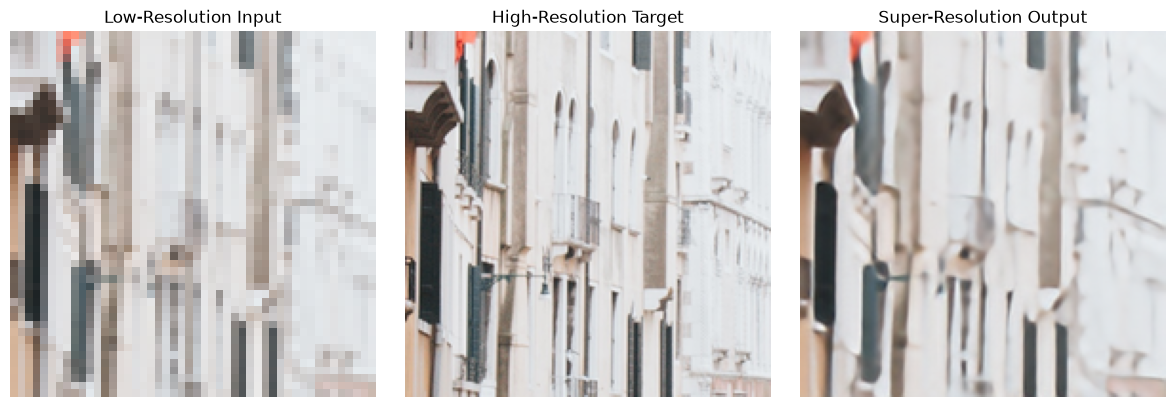

Epoch [1/200] Train Loss: 0.025986828 Val Loss: 0.024296475 Best: 0.024296475
Training time: 165.53s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


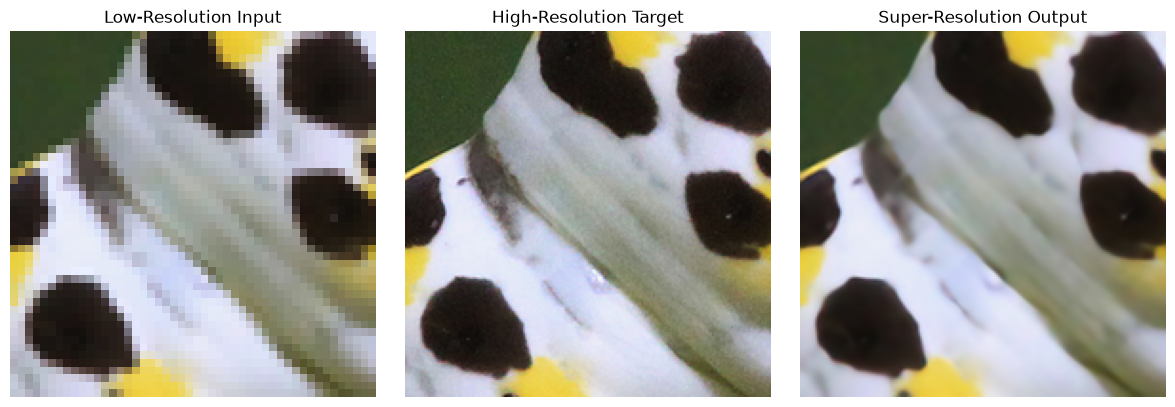

Epoch [2/200] Train Loss: 0.024195208 Val Loss: 0.024290381 Best: 0.024290381
Training time: 332.44s


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


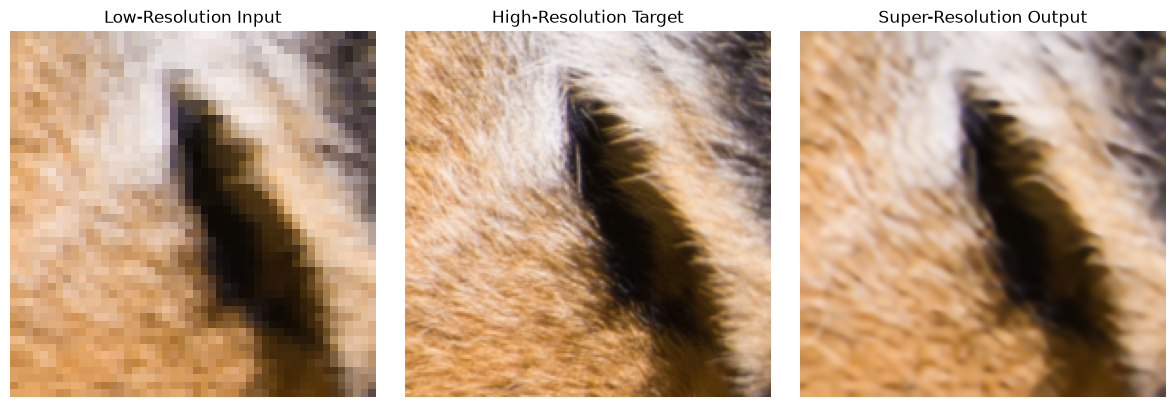

Epoch [3/200] Train Loss: 0.025573670 Val Loss: 0.024274307 Best: 0.024274307
Training time: 495.68s


100%|██████████| 200/200 [02:07<00:00,  1.56it/s]


Epoch [4/200] Train Loss: 0.024813250 Val Loss: 0.024292976 Best: 0.024274307
Training time: 658.55s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


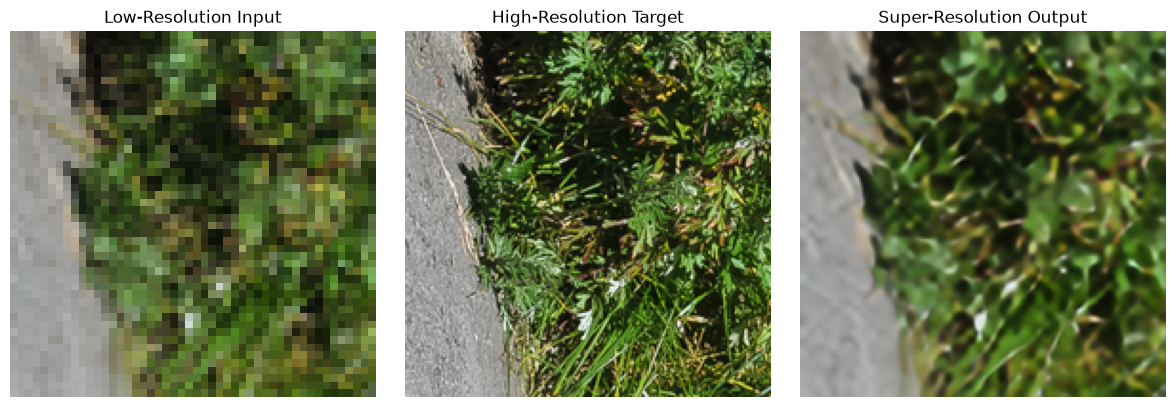

Epoch [5/200] Train Loss: 0.023925509 Val Loss: 0.024243426 Best: 0.024243426
Training time: 821.55s


100%|██████████| 200/200 [02:07<00:00,  1.56it/s]


Epoch [6/200] Train Loss: 0.024832586 Val Loss: 0.024269539 Best: 0.024243426
Training time: 984.28s


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


Epoch [7/200] Train Loss: 0.024669020 Val Loss: 0.024261420 Best: 0.024243426
Training time: 1147.75s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [21/200] Train Loss: 0.025419791 Val Loss: 0.024272879 Best: 0.024243426
Training time: 3428.07s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [22/200] Train Loss: 0.025112651 Val Loss: 0.024253355 Best: 0.024243426
Training time: 3590.94s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


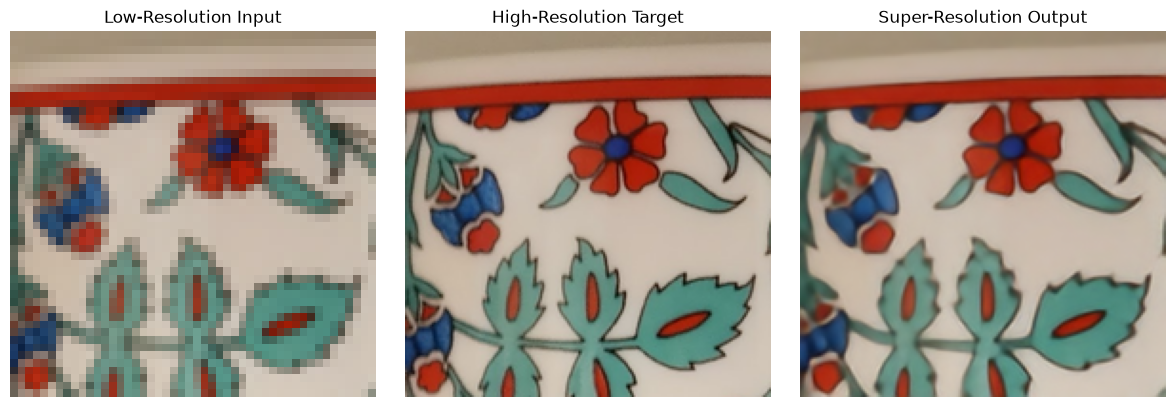

Epoch [23/200] Train Loss: 0.024519129 Val Loss: 0.024233064 Best: 0.024233064
Training time: 3753.87s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [24/200] Train Loss: 0.025715017 Val Loss: 0.024260897 Best: 0.024233064
Training time: 3916.21s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [25/200] Train Loss: 0.025043903 Val Loss: 0.024266566 Best: 0.024233064
Training time: 4078.39s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [38/200] Train Loss: 0.023761927 Val Loss: 0.024253404 Best: 0.024233064
Training time: 6187.87s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [39/200] Train Loss: 0.023695313 Val Loss: 0.024270101 Best: 0.024233064
Training time: 6349.87s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


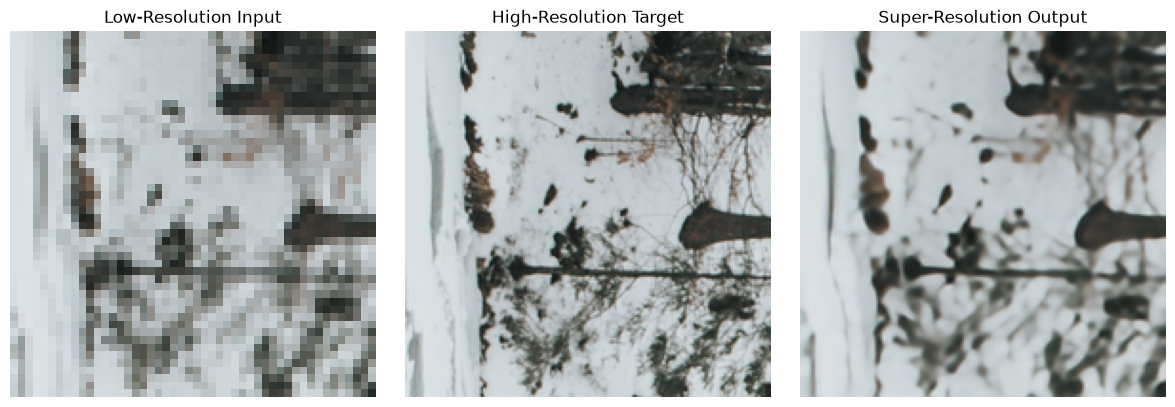

Epoch [40/200] Train Loss: 0.024511900 Val Loss: 0.024230391 Best: 0.024230391
Training time: 6512.70s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [41/200] Train Loss: 0.024921718 Val Loss: 0.024261028 Best: 0.024230391
Training time: 6674.85s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [42/200] Train Loss: 0.025500477 Val Loss: 0.024266902 Best: 0.024230391
Training time: 6837.17s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [50/200] Train Loss: 0.024377106 Val Loss: 0.024278689 Best: 0.024230391
Training time: 8139.43s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [51/200] Train Loss: 0.025038456 Val Loss: 0.024264468 Best: 0.024230391
Training time: 8301.87s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


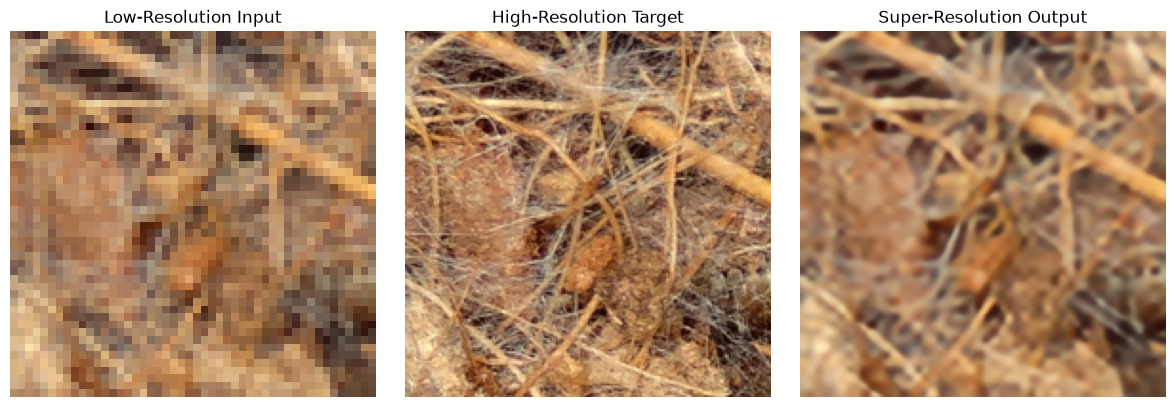

Epoch [52/200] Train Loss: 0.024766623 Val Loss: 0.024225408 Best: 0.024225408
Training time: 8464.51s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [53/200] Train Loss: 0.024549157 Val Loss: 0.024245022 Best: 0.024225408
Training time: 8626.85s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [54/200] Train Loss: 0.025106266 Val Loss: 0.024253625 Best: 0.024225408
Training time: 8789.16s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [68/200] Train Loss: 0.024312821 Val Loss: 0.024255734 Best: 0.024225408
Training time: 11066.47s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [69/200] Train Loss: 0.024637438 Val Loss: 0.024234718 Best: 0.024225408
Training time: 11229.04s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


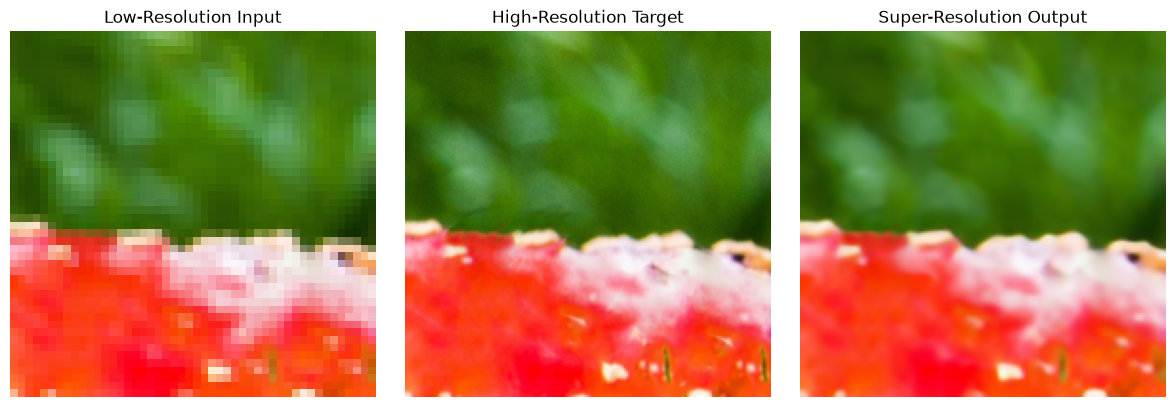

Epoch [70/200] Train Loss: 0.025554765 Val Loss: 0.024217661 Best: 0.024217661
Training time: 11391.68s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [71/200] Train Loss: 0.024484671 Val Loss: 0.024252644 Best: 0.024217661
Training time: 11553.77s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [72/200] Train Loss: 0.025675950 Val Loss: 0.024240161 Best: 0.024217661
Training time: 11716.05s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


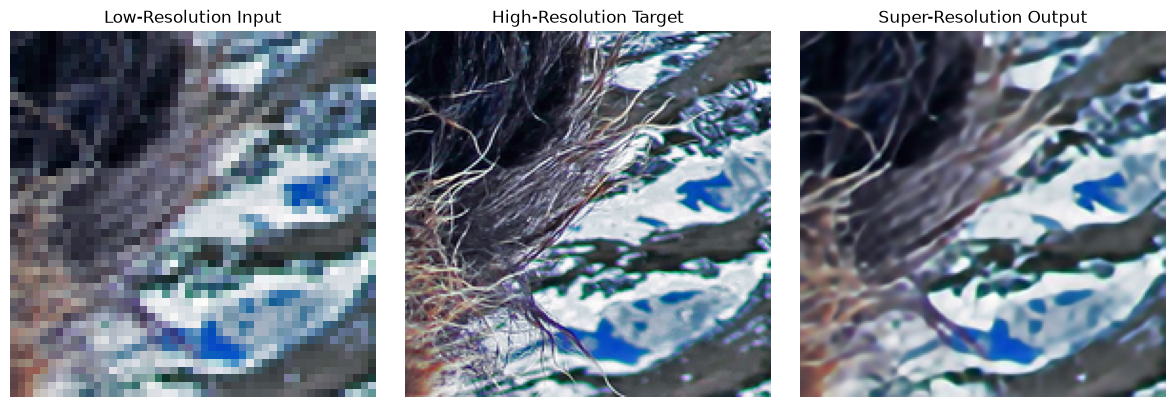

Epoch [73/200] Train Loss: 0.024908444 Val Loss: 0.024216971 Best: 0.024216971
Training time: 11878.71s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [74/200] Train Loss: 0.025453376 Val Loss: 0.024265018 Best: 0.024216971
Training time: 12040.53s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [75/200] Train Loss: 0.025085934 Val Loss: 0.024222929 Best: 0.024216971
Training time: 12202.85s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [76/200] Train Loss: 0.024845742 Val Loss: 0.024245902 Best: 0.024216971
Training time: 12365.38s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


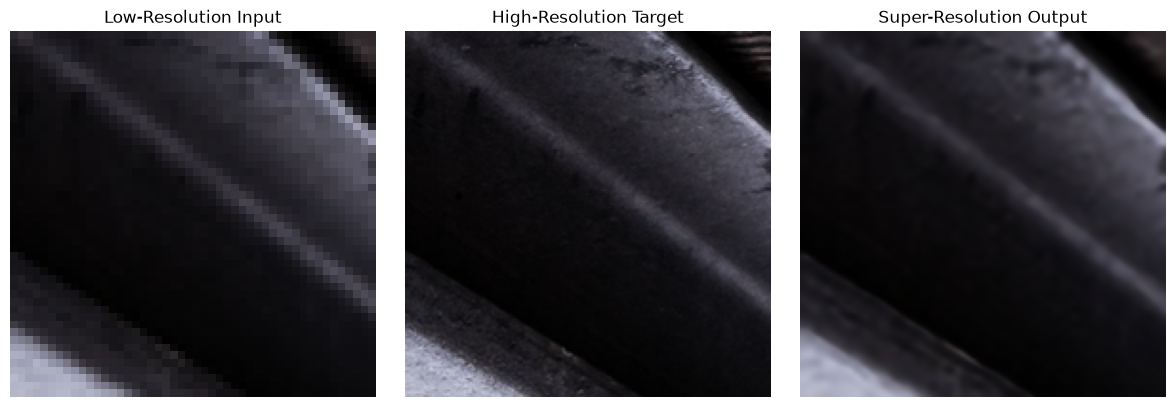

Epoch [77/200] Train Loss: 0.024004705 Val Loss: 0.024212074 Best: 0.024212074
Training time: 12527.83s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [78/200] Train Loss: 0.025398348 Val Loss: 0.024227981 Best: 0.024212074
Training time: 12690.42s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [79/200] Train Loss: 0.024617278 Val Loss: 0.024221656 Best: 0.024212074
Training time: 12852.95s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [100/200] Train Loss: 0.024883926 Val Loss: 0.024226644 Best: 0.024212074
Training time: 16260.46s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [101/200] Train Loss: 0.024953630 Val Loss: 0.024238837 Best: 0.024212074
Training time: 16422.15s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


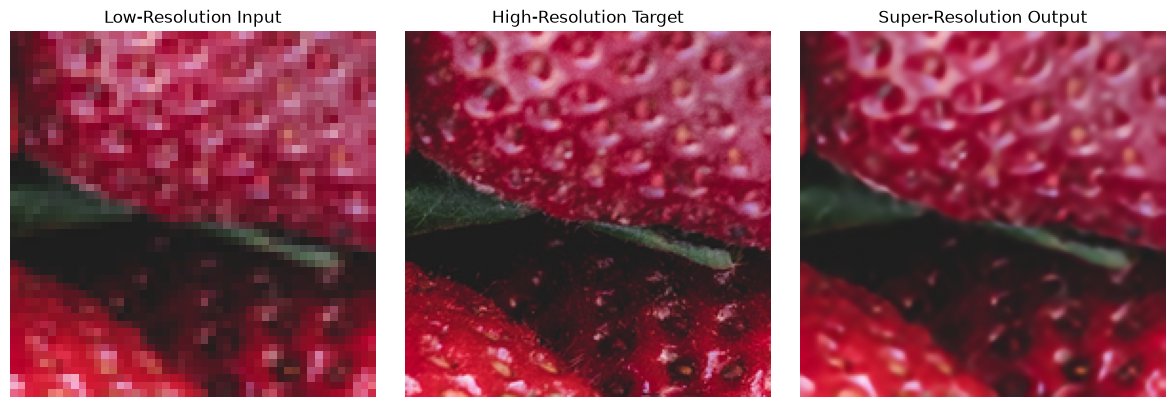

Epoch [102/200] Train Loss: 0.023844607 Val Loss: 0.024207797 Best: 0.024207797
Training time: 16584.55s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [103/200] Train Loss: 0.024663917 Val Loss: 0.024249900 Best: 0.024207797
Training time: 16746.95s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [104/200] Train Loss: 0.024810859 Val Loss: 0.024227639 Best: 0.024207797
Training time: 16908.88s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


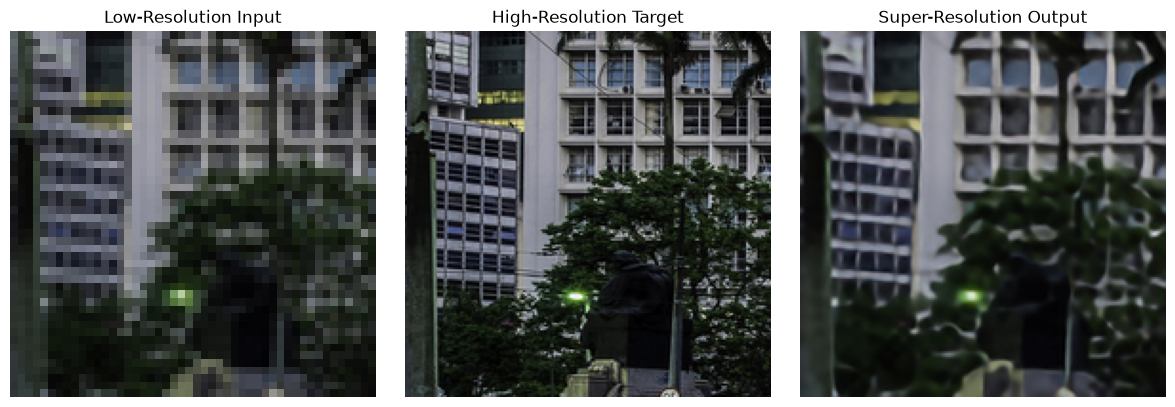

Epoch [105/200] Train Loss: 0.024648213 Val Loss: 0.024203464 Best: 0.024203464
Training time: 17071.36s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [106/200] Train Loss: 0.025328359 Val Loss: 0.024242044 Best: 0.024203464
Training time: 17233.97s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [107/200] Train Loss: 0.024713251 Val Loss: 0.024218935 Best: 0.024203464
Training time: 17396.45s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [118/200] Train Loss: 0.024662562 Val Loss: 0.024224757 Best: 0.024203464
Training time: 19182.75s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [119/200] Train Loss: 0.025266843 Val Loss: 0.024222537 Best: 0.024203464
Training time: 19345.18s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


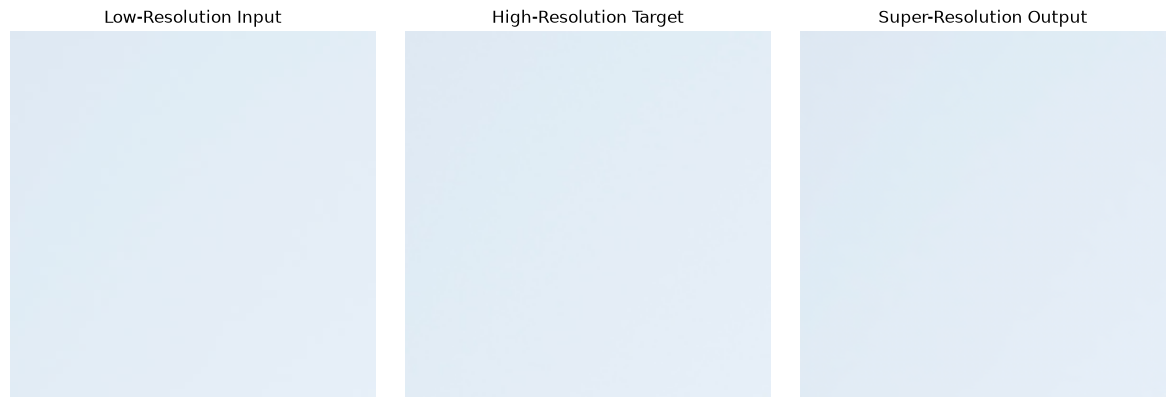

Epoch [120/200] Train Loss: 0.024939689 Val Loss: 0.024201769 Best: 0.024201769
Training time: 19507.50s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [121/200] Train Loss: 0.023853329 Val Loss: 0.024248148 Best: 0.024201769
Training time: 19670.28s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [122/200] Train Loss: 0.025171707 Val Loss: 0.024237907 Best: 0.024201769
Training time: 19832.77s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [143/200] Train Loss: 0.024696251 Val Loss: 0.024239703 Best: 0.024201769
Training time: 23248.29s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [144/200] Train Loss: 0.025184562 Val Loss: 0.024274574 Best: 0.024201769
Training time: 23410.71s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


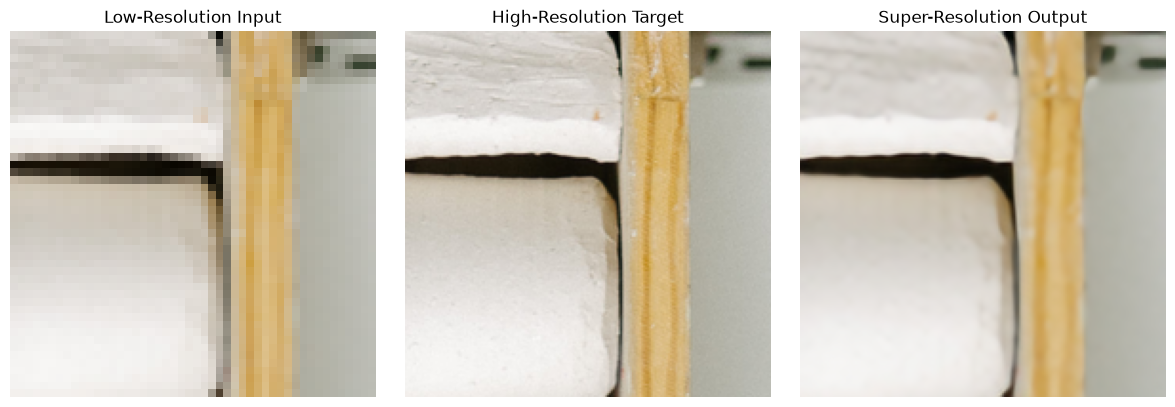

Epoch [145/200] Train Loss: 0.024123087 Val Loss: 0.024188548 Best: 0.024188548
Training time: 23573.04s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [146/200] Train Loss: 0.024611631 Val Loss: 0.024225701 Best: 0.024188548
Training time: 23735.72s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [147/200] Train Loss: 0.025597923 Val Loss: 0.024229975 Best: 0.024188548
Training time: 23898.42s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [161/200] Train Loss: 0.024241041 Val Loss: 0.024236285 Best: 0.024188548
Training time: 26169.61s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [162/200] Train Loss: 0.024950843 Val Loss: 0.024239653 Best: 0.024188548
Training time: 26331.78s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


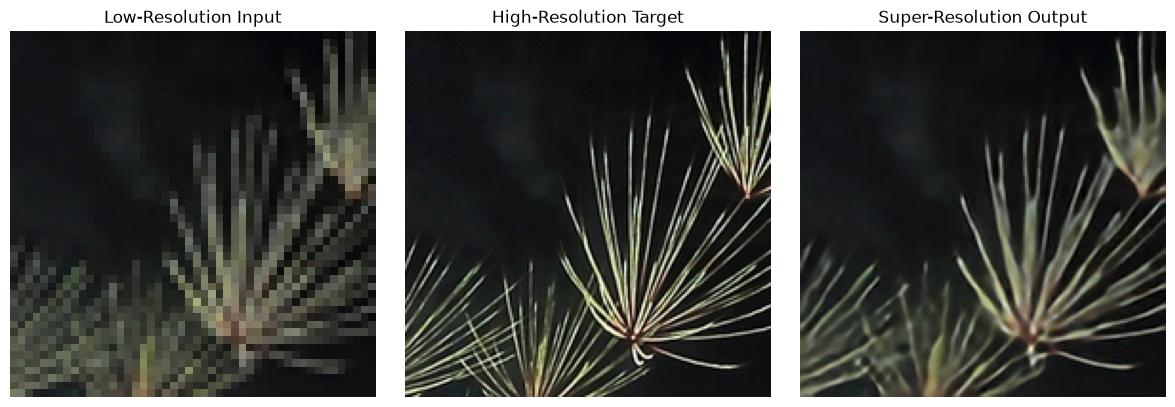

Epoch [163/200] Train Loss: 0.024031980 Val Loss: 0.024188460 Best: 0.024188460
Training time: 26494.11s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [164/200] Train Loss: 0.025209784 Val Loss: 0.024267384 Best: 0.024188460
Training time: 26656.07s


100%|██████████| 200/200 [02:52<00:00,  1.16it/s]


Epoch [165/200] Train Loss: 0.024828108 Val Loss: 0.024216450 Best: 0.024188460
Training time: 26863.55s


...

100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


Epoch [176/200] Train Loss: 0.024909952 Val Loss: 0.024210758 Best: 0.024188460
Training time: 28655.83s


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


Epoch [177/200] Train Loss: 0.024892019 Val Loss: 0.024208324 Best: 0.024188460
Training time: 28819.45s


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


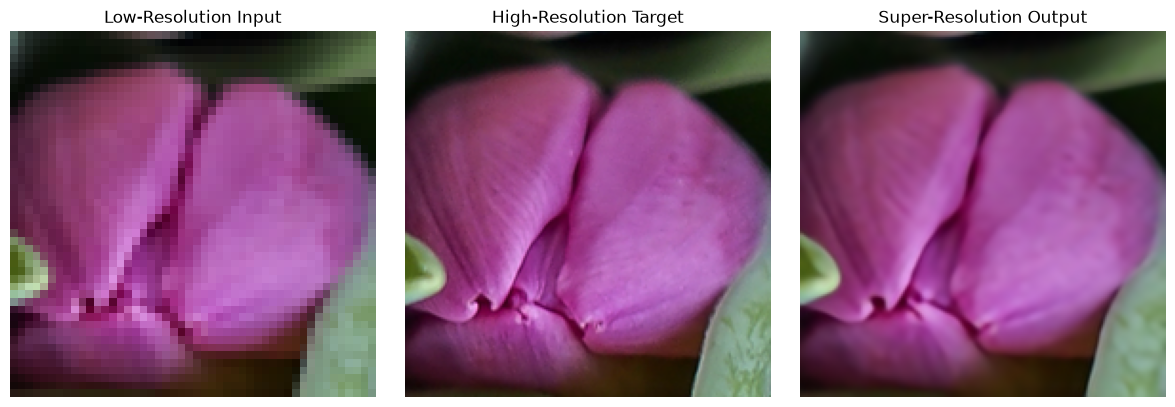

Epoch [178/200] Train Loss: 0.025157559 Val Loss: 0.024187945 Best: 0.024187945
Training time: 28983.23s


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


Epoch [179/200] Train Loss: 0.023757792 Val Loss: 0.024251043 Best: 0.024187945
Training time: 29146.49s


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


Epoch [180/200] Train Loss: 0.025550247 Val Loss: 0.024259102 Best: 0.024187945
Training time: 29309.61s


...

100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


Epoch [197/200] Train Loss: 0.024801902 Val Loss: 0.024195496 Best: 0.024187945
Training time: 32092.42s


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


Epoch [198/200] Train Loss: 0.024545259 Val Loss: 0.024235436 Best: 0.024187945
Training time: 32256.26s


100%|██████████| 200/200 [02:14<00:00,  1.49it/s]


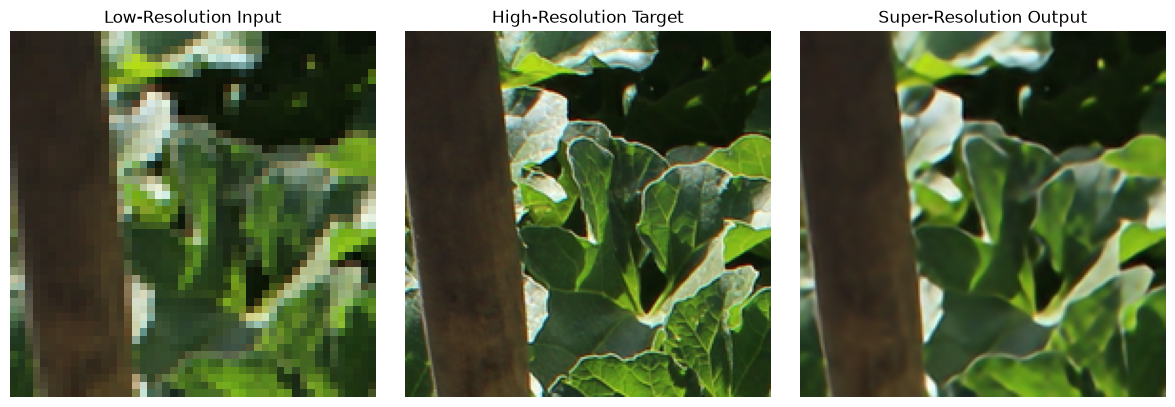

Epoch [199/200] Train Loss: 0.024059591 Val Loss: 0.024184469 Best: 0.024184469
Training time: 32427.51s


100%|██████████| 200/200 [02:11<00:00,  1.52it/s]


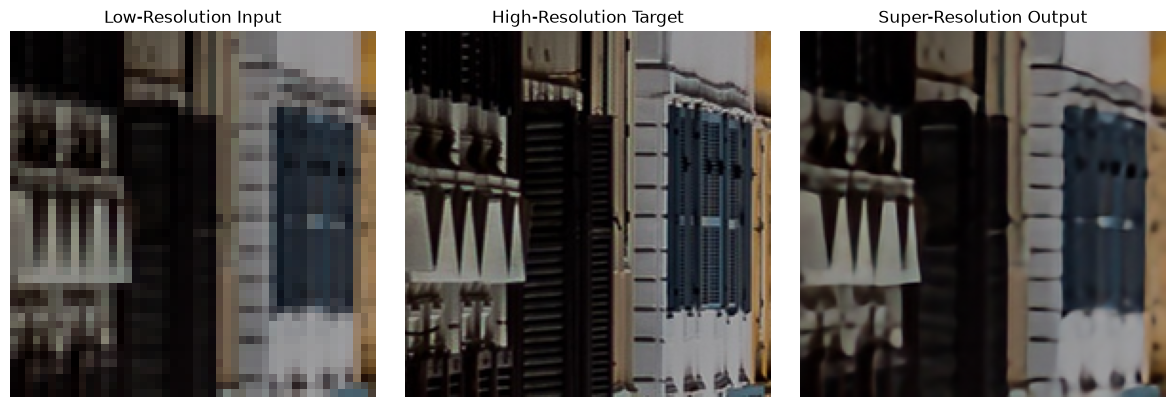

Epoch [200/200] Train Loss: 0.024556259 Val Loss: 0.024182326 Best: 0.024182326
Training time: 32598.02s


In [6]:
import random
import time
import matplotlib.pyplot as plt
patience = MAX_PATIENCE
train_losses = []
test_losses = []
time_start = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for lr_images, hr_images in tqdm(train_loader):
        lr_images = lr_images.to(device)
        hr_images = hr_images.to(device)
        optimizer.zero_grad()
        with autocast:
            outputs = model(lr_images, False)
            loss = criterion(outputs, hr_images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    #scheduler.step()

    # Validation
    model.eval()
    running_test_loss = 0.0
    with torch.inference_mode():
        for lr_images, hr_images in tqdm(test_loader):
            lr_images = lr_images.to(device)
            hr_images = hr_images.to(device)
            with autocast:
                outputs = model(lr_images)
                loss = criterion(outputs, hr_images)
            running_test_loss += loss.item()
    test_loss = running_test_loss / len(test_loader)
    test_losses.append(test_loss)

    # Visualization
    if test_loss <= best_loss:
        best_loss = test_loss
        torch.save(model.state_dict(), f"weights/dlgsanet_{STEP:02d}.pth")
        with torch.inference_mode():
            random_idx = random.randrange(len(train_dataset))
            lr_image, hr_image = train_dataset[random_idx]
            lr_input = lr_image.unsqueeze(0).to(device)
            output = model(lr_input).squeeze(0).cpu()
            lr_image = lr_image.cpu()
            hr_image = hr_image.cpu()
        # [C, H, W] -> [H, W, C]
        lr_image = lr_image.permute(1, 2, 0).numpy()
        hr_image = hr_image.permute(1, 2, 0).numpy()
        output = output.permute(1, 2, 0).numpy()
        # Clamp because model output can slightly exceed [0, 1]
        lr_image = lr_image.clip(0, 1)
        hr_image = hr_image.clip(0, 1)
        output = output.clip(0, 1)

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(lr_image)
        axs[0].set_title("Low-Resolution Input")
        axs[0].axis("off")

        axs[1].imshow(hr_image)
        axs[1].set_title("High-Resolution Target")
        axs[1].axis("off")

        axs[2].imshow(output)
        axs[2].set_title("Super-Resolution Output")
        axs[2].axis("off")

        plt.tight_layout()
        plt.show()

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.9f} "
        f"Val Loss: {test_loss:.9f} "
        f"Best: {best_loss:.9f}"
    )
    print(f"Training time: {time.time() - time_start:.2f}s")

    if test_loss > best_loss:
        patience -= 1
        if patience == 0:
            print("Early stopping triggered.")
            break
    else:
        patience = round(MAX_PATIENCE - (MAX_PATIENCE - MIN_PATIENCE) * (epoch + 1) / EPOCHS)
        patience = max(5, patience)

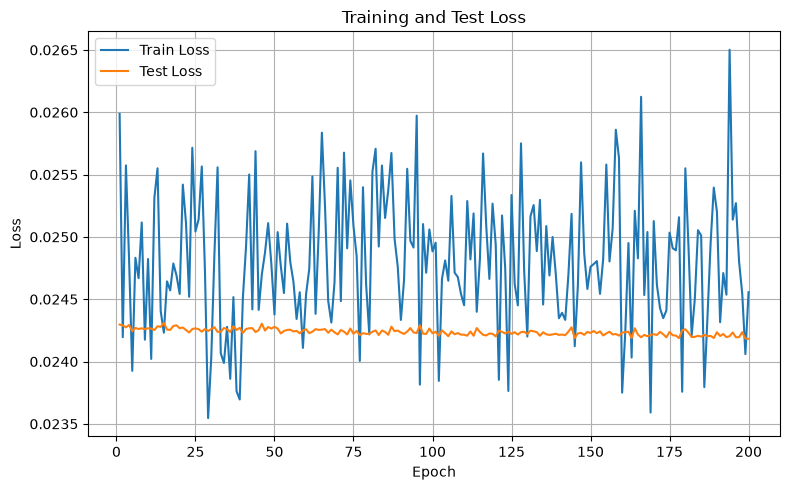

In [7]:
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
import cv2
import numpy as np
from torchvision.transforms import v2
from skimage.metrics import structural_similarity as compare_ssim
def calculate_psnr(img1, img2):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf'),0  # Perfect match
    max_pixel = 1
    psnr = 10 * np.log10(max_pixel ** 2 / mse)
    return psnr,mse

def calculate_ssim(img1, img2, rgb=False):
    if rgb:
        img1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
        img2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    ssim, _ = compare_ssim(img1, img2, full=True, data_range=1.0,)
    return ssim

to_tensor = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

In [9]:
model.load_state_dict(torch.load(f"weights/dlgsanet_{STEP:02d}.pth", map_location=device))

def evaluate_test_loader(test_loader):
    model.eval()

    psnr_scores = []
    ssim_scores = []

    with torch.inference_mode():
        for lr_images, hr_images in tqdm(test_loader):
            lr_images = lr_images.to(device)
            hr_images = hr_images.to(device)
            with autocast:
                outputs = model(lr_images)
            outputs = outputs.clamp(0, 1).float()
            # NCHW -> NHWC
            outputs = outputs.cpu().permute(0, 2, 3, 1).numpy()
            hr_images = hr_images.cpu().permute(0, 2, 3, 1).numpy()

            for output, hr in zip(outputs, hr_images):
                psnr, _ = calculate_psnr(output, hr)
                ssim = calculate_ssim(output, hr)

                psnr_scores.append(psnr)
                ssim_scores.append(ssim)

    results = {
        "psnr": {
            "min": float(np.min(psnr_scores)),
            "mean": float(np.mean(psnr_scores)),
            "max": float(np.max(psnr_scores)),
        },
        "ssim": {
            "min": float(np.min(ssim_scores)),
            "mean": float(np.mean(ssim_scores)),
            "max": float(np.max(ssim_scores)),
        },
    }

    print(
        f"PSNR: min={results['psnr']['min']:.4f}, "
        f"mean={results['psnr']['mean']:.4f}, "
        f"max={results['psnr']['max']:.4f}"
    )
    print(
        f"SSIM: min={results['ssim']['min']:.4f}, "
        f"mean={results['ssim']['mean']:.4f}, "
        f"max={results['ssim']['max']:.4f}"
    )

    return results
results = evaluate_test_loader(final_test_loader)

100%|██████████| 100/100 [02:02<00:00,  1.23s/it]

PSNR: min=20.1840, mean=28.8624, max=44.0602
SSIM: min=0.5410, mean=0.8328, max=0.9902


In [10]:
from PIL import Image
def evaluate_bicubic(test_loader):
    psnr_scores = []
    ssim_scores = []

    for lr_images, hr_images in tqdm(test_loader):
        for lr, hr in zip(lr_images, hr_images):
            lr = lr.permute(1, 2, 0).numpy()
            hr = hr.permute(1, 2, 0).numpy()

            # LR tensor [0,1] -> PIL
            lr_pil = Image.fromarray(
                (lr * 255).clip(0, 255).astype(np.uint8)
            )

            # PIL bicubic upscale
            bicubic_pil = lr_pil.resize(
                (hr.shape[1], hr.shape[0]),
                Image.Resampling.BICUBIC,
            )

            # PIL -> [0,1] float
            bicubic = np.asarray(bicubic_pil).astype(np.float32) / 255.0

            psnr, _ = calculate_psnr(bicubic, hr)
            ssim = calculate_ssim(bicubic, hr)

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

    results = {
        "psnr": {
            "min": float(np.min(psnr_scores)),
            "mean": float(np.mean(psnr_scores)),
            "max": float(np.max(psnr_scores)),
        },
        "ssim": {
            "min": float(np.min(ssim_scores)),
            "mean": float(np.mean(ssim_scores)),
            "max": float(np.max(ssim_scores)),
        },
    }

    print(
        f"Bicubic PSNR: "
        f"min={results['psnr']['min']:.4f}, "
        f"mean={results['psnr']['mean']:.4f}, "
        f"max={results['psnr']['max']:.4f}"
    )

    print(
        f"Bicubic SSIM: "
        f"min={results['ssim']['min']:.4f}, "
        f"mean={results['ssim']['mean']:.4f}, "
        f"max={results['ssim']['max']:.4f}"
    )

    return results

bicubic_results = evaluate_bicubic(final_test_loader)

100%|██████████| 100/100 [00:30<00:00,  3.25it/s]

Bicubic PSNR: min=16.4720, mean=26.6952, max=37.9498
Bicubic SSIM: min=0.4498, mean=0.7679, max=0.9810


In [11]:
import json

log = {
    "model_type": "DLGSANet",
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "psnr": results["psnr"]["mean"],
    "ssim": results["ssim"]["mean"],
}

with open("results.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(log) + "\n")